# 短期予測とモデル比較

このNotebookでは、これまで未実装だった次の部分を追加する。

1. spike magnitudeを強度のジャンプ量に反映するHawkes II
2. spike magnitudeを減衰時間に反映するHawkes III
3. persistence modelとの比較
4. 論文の式(15)による1〜14日先予測
5. MAE・重み付きAccuracy・MCCによる評価

論文ではエリア $a$、時刻コード $t$ ごとに独立した日次系列を作る。ここでは既存Notebookに合わせ、Tokyo・timecode 15を代表例として最後まで計算する。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

DATA_DIR = PROJECT_DATA_DIR / "processed"
AREA = "Tokyo"
TIME_CODE = 15

u_wide = pd.read_csv(
    DATA_DIR / "u_dict" / f"u_{AREA}.csv", index_col=0, parse_dates=True
)
x_wide = pd.read_csv(
    DATA_DIR / "x_dict" / f"x_{AREA}.csv", index_col=0, parse_dates=True
)

series = (
    pd
    .DataFrame({
        "u": u_wide[str(TIME_CODE)].astype(int),
        "x": x_wide[str(TIME_CODE)].astype(float),
    })
    .dropna()
    .sort_index()
)

# 論文の対象期間に厳密に合わせる
series = series.loc["2016-04-01":"2022-03-31"]
series.describe()

,u,x
count,2191.000000,2191.000000
mean,0.053400,1.561824
std,0.224882,12.168132
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,177.000000


## モデル

観測前の強度を $\lambda_d^-$、観測後を $\lambda_d^+$ と書く。

### Hawkes I

$$\lambda_d^- = \mu + \alpha(\lambda_{d-1}^+-\mu),\qquad \lambda_d^+=\lambda_d^-+\gamma u_d$$

### Hawkes II

$$\gamma_d=\gamma_0\left(1-\exp(-x_d/x_{0,d})\right)$$

$x_{0,d}$ はday $d$までに観測されたspike magnitudeの平均。大きいスパイクほど強度を大きくジャンプさせる。

### Hawkes III

$$\tau_d=\tau_0\left(1-\exp(-x_d/x_{0,d})\right)$$

イベント $i$ の寄与は $\gamma\exp(-(d-i)/\tau_i)$ で減衰する。イベントごとに $\tau_i$ が違うため、Hawkes Iと同じ1変数の再帰式にはできない。

In [2]:
EPS = 1e-8


def running_spike_mean(x):
    x = np.asarray(x, dtype=float)
    is_spike = x > 0
    count = np.cumsum(is_spike)
    total = np.cumsum(x)
    fallback = x[is_spike].mean() if is_spike.any() else 1.0
    return np.divide(total, count, out=np.full_like(x, fallback), where=count > 0)


def intensities_hawkes1(u, mu, tau, gamma):
    alpha = np.exp(-1.0 / tau)
    lam = np.empty(len(u), dtype=float)
    post = mu
    for d, event in enumerate(u):
        lam[d] = mu + alpha * (post - mu)
        post = lam[d] + gamma * event
    return np.clip(lam, EPS, 1 - EPS)


def intensities_hawkes2(u, x, mu, tau, gamma0):
    alpha = np.exp(-1.0 / tau)
    x0 = running_spike_mean(x)
    jump = gamma0 * (1.0 - np.exp(-x / np.maximum(x0, EPS)))
    lam = np.empty(len(u), dtype=float)
    post = mu
    for d, event in enumerate(u):
        lam[d] = mu + alpha * (post - mu)
        post = lam[d] + jump[d] * event
    return np.clip(lam, EPS, 1 - EPS)


def intensities_hawkes3(u, x, mu, tau0, gamma):
    # 各イベントが固有のtau_iを持つmarked Hawkesを直接加算する
    u = np.asarray(u, dtype=int)
    x = np.asarray(x, dtype=float)
    x0 = running_spike_mean(x)
    tau_event = tau0 * (1.0 - np.exp(-x / np.maximum(x0, EPS)))
    lam = np.full(len(u), mu, dtype=float)
    for i in np.flatnonzero(u):
        if i + 1 >= len(u):
            continue
        lags = np.arange(1, len(u) - i, dtype=float)
        lam[i + 1 :] += gamma * np.exp(-lags / max(tau_event[i], EPS))
    return np.clip(lam, EPS, 1 - EPS)


def bernoulli_nll(lam, u):
    return -np.sum(u * np.log(lam) + (1 - u) * np.log(1 - lam))

## パラメータ推定

論文はBayesian approachを採用している。ここでは再実行しやすい基準実装として、弱い正規事前を加えたMAP推定を使う。これは論文のモデル式の再現部分と、推定器に関する実装上の選択を区別するためである。

パラメータは対数変換して最適化し、$\mu,\tau,\gamma>0$ を保証する。強度が1以上になる候補には罰則を与える。

In [3]:
def fit_model(model, u, x):
    u = np.asarray(u, dtype=int)
    x = np.asarray(x, dtype=float)
    mu0 = np.clip(u.mean(), 1e-3, 0.2)
    theta0 = np.log([mu0, 5.0, 0.15])

    def objective(theta):
        mu, scale, gamma = np.exp(theta)
        if model == "Hawkes I":
            lam = intensities_hawkes1(u, mu, scale, gamma)
        elif model == "Hawkes II":
            lam = intensities_hawkes2(u, x, mu, scale, gamma)
        elif model == "Hawkes III":
            lam = intensities_hawkes3(u, x, mu, scale, gamma)
        else:
            raise ValueError(model)
        # log-parameterに対する弱い正規事前
        prior_penalty = 0.5 * np.sum(((theta - theta0) / 2.0) ** 2)
        return bernoulli_nll(lam, u) + prior_penalty

    result = minimize(
        objective, theta0, method="L-BFGS-B", bounds=[(-9, -0.01), (-4, 6), (-9, -0.01)]
    )
    mu, scale, gamma = np.exp(result.x)
    return {
        "model": model,
        "mu": mu,
        "tau": scale,
        "gamma": gamma,
        "objective": result.fun,
        "success": result.success,
        "message": result.message,
    }


# 最後の365日を評価期間にする
train = series.iloc[:-365]
test = series.iloc[-365:]
fits = [
    fit_model(name, train.u, train.x)
    for name in ["Hawkes I", "Hawkes II", "Hawkes III"]
]
pd.DataFrame(fits)

,model,mu,tau,gamma,objective,success,message
0,Hawkes I,0.002085,1.727058,0.715781,60.183831,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,Hawkes II,0.002103,2.199472,0.643010,62.073096,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,Hawkes III,0.002101,3.196753,0.443000,62.039643,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


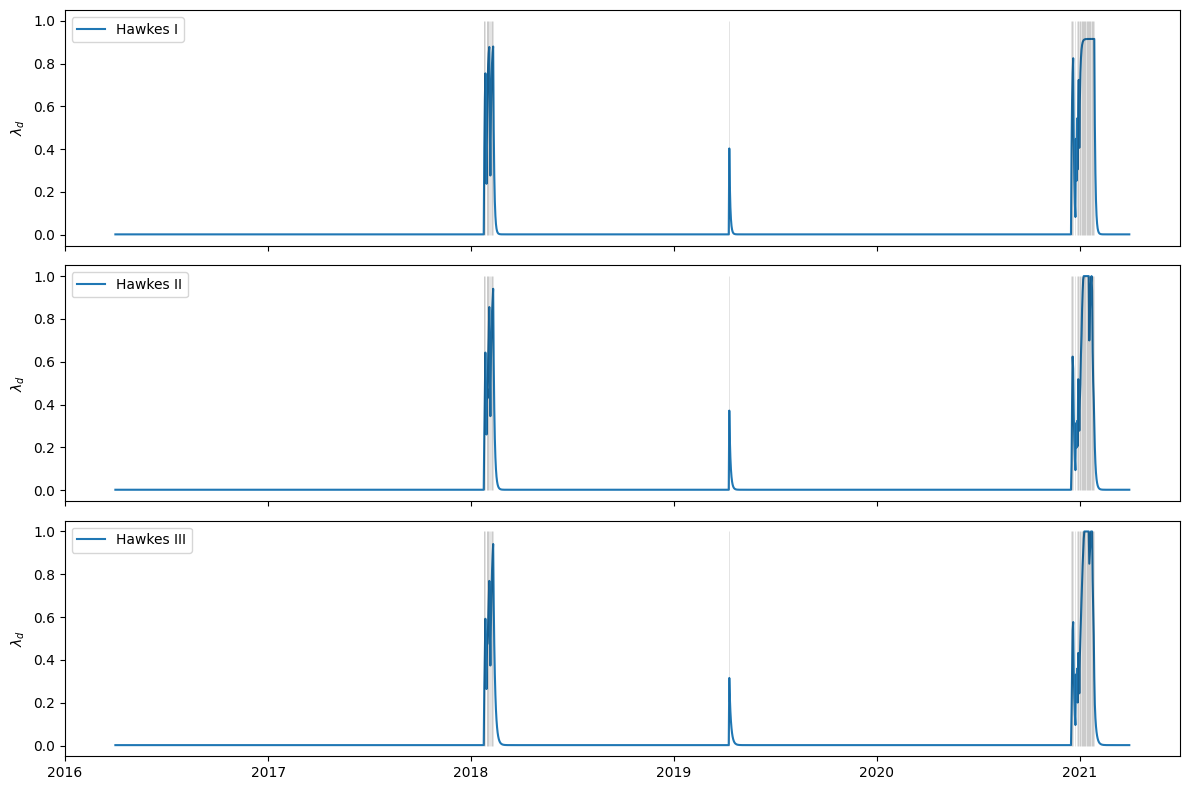

In [4]:
# 学習期間内の適合を可視化
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, fit in zip(axes, fits):
    if fit["model"] == "Hawkes I":
        lam = intensities_hawkes1(train.u.values, fit["mu"], fit["tau"], fit["gamma"])
    elif fit["model"] == "Hawkes II":
        lam = intensities_hawkes2(
            train.u.values, train.x.values, fit["mu"], fit["tau"], fit["gamma"]
        )
    else:
        lam = intensities_hawkes3(
            train.u.values, train.x.values, fit["mu"], fit["tau"], fit["gamma"]
        )
    ax.plot(train.index, lam, label=fit["model"])
    ax.vlines(train.index[train.u.eq(1)], 0, 1, color="black", alpha=0.15, lw=0.5)
    ax.set_ylabel(r"$\lambda_d$")
    ax.legend()
plt.tight_layout()

## 1〜14日先予測

論文の式(15)に従い、将来のイベント期待値を $\hat u_{d+k}=\hat\lambda_{d+k-1}$ と置いて強度を反復する。分類は論文と同じ $\delta=0.5$ を使う。

Hawkes II・IIIで将来必要になるmagnitudeは、論文のPersistence model（式17）に従って起点日の $x_d$ を予測期間中持続させる。Persistenceの発生確率は、起点までのデータから直近状態に対する経験的条件付き確率を計算する。

In [5]:
def paper_forecast(model, history_u, history_x, params, horizon=14):
    u = np.asarray(history_u, dtype=int)
    x = np.asarray(history_x, dtype=float)
    mu, tau, gamma = params["mu"], params["tau"], params["gamma"]
    alpha = np.exp(-1.0 / tau)
    x_positive = x[x > 0]
    x0 = x_positive.mean() if len(x_positive) else 1.0

    if model == "Hawkes I":
        lam = intensities_hawkes1(u, mu, tau, gamma)[-1] + gamma * u[-1]
        gamma_forecast = gamma
    elif model == "Hawkes II":
        gamma_last = gamma * (1 - np.exp(-x[-1] / x0))
        lam = intensities_hawkes2(u, x, mu, tau, gamma)[-1] + gamma_last * u[-1]
        gamma_forecast = gamma_last
    else:
        # 起点日のmagnitudeを持続させ、対応するdecayを将来区間で使う
        tau_forecast = tau * (1 - np.exp(-x[-1] / x0)) if x[-1] > 0 else tau
        alpha = np.exp(-1.0 / max(tau_forecast, EPS))
        lam = intensities_hawkes3(u, x, mu, tau, gamma)[-1] + gamma * u[-1]
        gamma_forecast = gamma

    beta = mu * (1 - alpha)
    probs = np.empty(horizon)
    for k in range(horizon):
        u_hat = lam
        lam = alpha * lam + beta + gamma_forecast * u_hat
        probs[k] = np.clip(u_hat, 0, 1)
    return probs


def persistence_forecast(history_u, horizon=14):
    u = np.asarray(history_u, dtype=int)
    state = u[-1]
    mask = u[:-1] == state
    probability = u[1:][mask].mean() if mask.any() else u.mean()
    return np.full(horizon, probability)


def make_forecasts(series, fits, horizon=14, step=1):
    rows = []
    fit_map = {f["model"]: f for f in fits}
    first_test_pos = len(series) - 365
    for origin in range(first_test_pos - 1, len(series) - horizon, step):
        hu = series.u.iloc[: origin + 1].values
        hx = series.x.iloc[: origin + 1].values
        actual = series.u.iloc[origin + 1 : origin + 1 + horizon].values
        for model in ["Hawkes I", "Hawkes II", "Hawkes III"]:
            prob = paper_forecast(model, hu, hx, fit_map[model], horizon)
            for h, (p, y) in enumerate(zip(prob, actual), start=1):
                rows.append((series.index[origin], model, h, p, y))
        for h, (p, y) in enumerate(
            zip(persistence_forecast(hu, horizon), actual), start=1
        ):
            rows.append((series.index[origin], "Persistence", h, p, y))
    return pd.DataFrame(rows, columns=["origin", "model", "horizon", "prob", "actual"])


forecast = make_forecasts(series, fits)
forecast.head()

,origin,model,horizon,prob,actual
0,2021-03-31,Hawkes I,1,0.002085,0
1,2021-03-31,Hawkes I,2,0.003578,0
2,2021-03-31,Hawkes I,3,0.005483,0
3,2021-03-31,Hawkes I,4,0.007915,0
4,2021-03-31,Hawkes I,5,0.011018,0


## 評価指標

$$MAE=\frac{1}{N}\sum_i|u_i-\hat p_i|$$

MCCはクラス不均衡下でも陽性・陰性の両方を使う相関指標。分類閾値は論文と同じ $\delta=0.5$ とする。

論文の式(21)は $WACC=1-[a FN+(2-a)FP]/N$。論文と同じ $a=1.6$ を使うため、FNはFPの4倍の重みになる。

In [6]:
def classification_metrics(actual, prob, threshold=0.5, a=1.6):
    actual = np.asarray(actual, dtype=int)
    pred = (np.asarray(prob) >= threshold).astype(int)
    tp = np.sum((actual == 1) & (pred == 1))
    tn = np.sum((actual == 0) & (pred == 0))
    fp = np.sum((actual == 0) & (pred == 1))
    fn = np.sum((actual == 1) & (pred == 0))
    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = ((tp * tn - fp * fn) / denom) if denom else np.nan
    n = tp + tn + fp + fn
    weighted_accuracy = 1.0 - (a * fn + (2.0 - a) * fp) / n
    return pd.Series({"weighted_accuracy": weighted_accuracy, "MCC": mcc})


classification_threshold = 0.5
rows = []
for (model, horizon), g in forecast.groupby(["model", "horizon"]):
    cls = classification_metrics(g.actual, g.prob, classification_threshold)
    rows.append({
        "model": model,
        "horizon": horizon,
        "MAE": np.mean(np.abs(g.actual - g.prob)),
        **cls.to_dict(),
    })
metrics = pd.DataFrame(rows)
metrics.groupby("model")[["MAE", "weighted_accuracy", "MCC"]].mean().sort_values("MAE")

,MAE,weighted_accuracy,MCC
model,,,
Persistence,0.174932,0.822890,0.425970
Hawkes II,0.183111,0.709821,0.059721
Hawkes I,0.190451,0.900244,0.576841
Hawkes III,0.195038,0.721510,0.124850


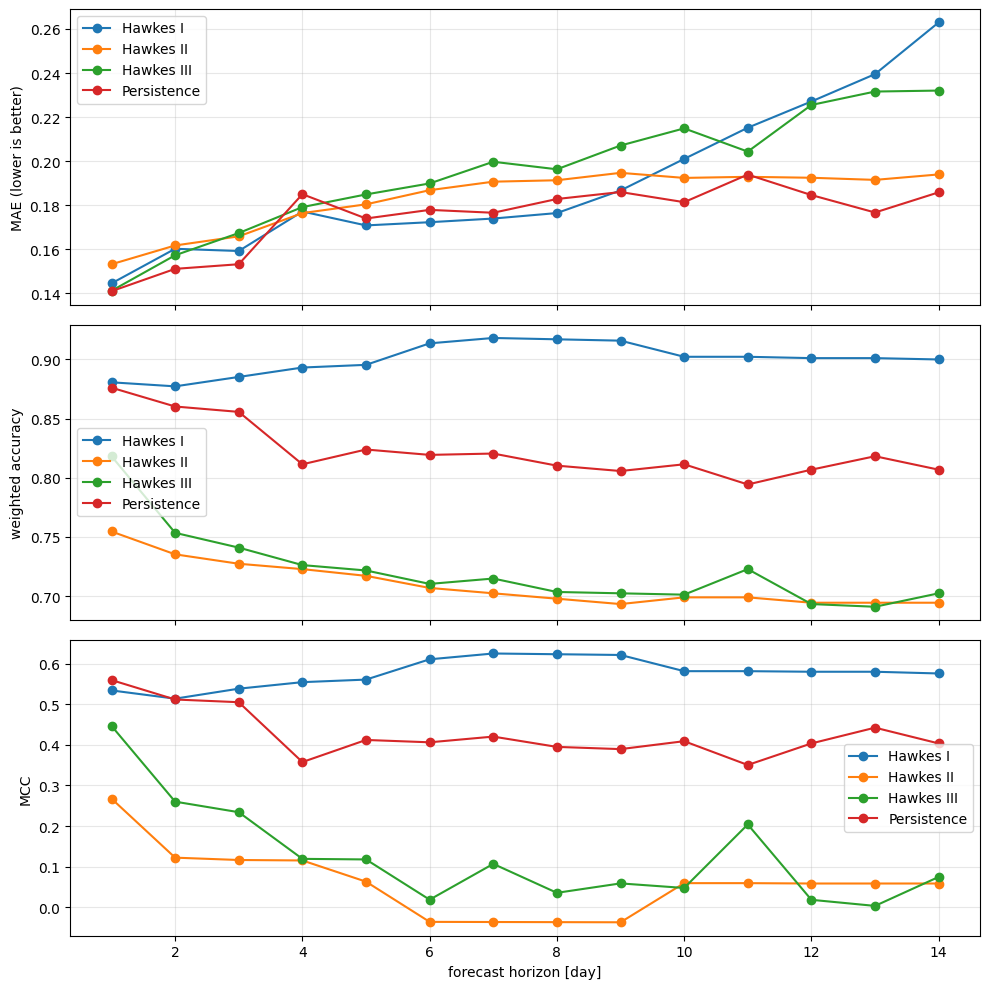

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for model, g in metrics.groupby("model"):
    g = g.sort_values("horizon")
    axes[0].plot(g.horizon, g.MAE, marker="o", label=model)
    axes[1].plot(g.horizon, g.weighted_accuracy, marker="o", label=model)
    axes[2].plot(g.horizon, g.MCC, marker="o", label=model)
axes[0].set_ylabel("MAE (lower is better)")
axes[1].set_ylabel("weighted accuracy")
axes[2].set_ylabel("MCC")
axes[2].set_xlabel("forecast horizon [day]")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()

## 論文結果との照合

論文ではHawkes IIがHawkes I・III・Persistenceより良く、予測期間が長いほど差が明瞭になった。上の図でも同じ順位になるかを確認する。

完全な表の再現には、全432系列について同じ推定と日次rolling forecastを実施し、論文と同じ対象系列を集計する必要がある。このNotebookでは、式・推定・複数日予測・評価までの再現可能な最小単位をTokyo/timecode 15で示した。